# UNIVERSIDAD NACIONAL DE HURLINGHAM
## Inst. de Tecnología e Ingeniería
### PARSEO Y GENERACIÓN DE CÓDIGO
#### Prof: Mag. Ing. Pablo Pandolfo
#### Examen Parcial - Mayo 2026

* **ALUMNO**:
* **DNI**:

#### NOTA: EL EXAMEN ESCRITO ES UN DOCUMENTO DE GRAN IMPORTANCIA PARA LA EVALUACIÓN DE LOS CONOCIMIENTOS ADQUIRIDOS, POR LO TANTO, SE SOLICITA LEER ATENTAMENTE LO SIGUIENTE

* Responda claramente cada punto, detallando con la mayor precisión posible lo solicitado.
* Sea prolijo y ordenado en el desarrollo de los temas.
* Sea cuidadoso con las faltas de ortografía y sus oraciones.
* No desarrollar el examen en lápiz.
* Aprobación del examen: Con nota mayor o igual a 4 (cuatro)
* Condiciones de aprobación: 60%
* Duración de examen: 3 horas.

PP presenta un LP que denomina **BRA**. Es un lenguaje muy simple que está diseñado, específicamente, para poseer un LP concreto sobre el que se pueda analizar la construcción de un compilador básico. Informalmente se define de esta manera:
* El único **tipo de datos** es entero
* Todos los **identificadores** son declarados implícitamente y con una longitud máxima de 4 caracteres
* Los identificadores deben comenzar con una letra y están compuestos de letras, dígitos y guiones bajos. No puede terminar con guion tampoco tener dos guiones seguidos
* Las **constantes** son secuencias de dígitos (números enteros)
* Hay dos tipos de **sentencias**:
	* **Asignación**: 
		* ID ::= Expressão;
		* Expressão es infija y se construye con identificadores, constantes y los operadores + y -; los paréntesis están permitidos
	* **Entrada/Salida**:
		* ler(lista de IDs);
		* escrever(lista de Expressões);
* Cada sentencia termina con un "punto y coma" (;)
* El cuerpo de un programa está delimitado por começo e final
* **começo**, **final**, **ler**, **escrever** son palabras reservadas y deben escribirse en minúsculas
* El siguiente es un programa fuente en BRA:

```
começo
	ler(a,b);
	cc ::= a + (b - 2);
	escrever(cc, a+4);
final
```

* Cadena de estudio: ```começo A ::= BB - 34 + A; final```
* Cadena de estudio min: ```começo A ::= 1; final```
* Aplíquese lo visto (título y desarrollo de cada tema)

## Checklist

1. Tabla: Token - Patrón (ER)
2. Tabla: Entrada - Buffer - Acción
3. Diagrama de Transiciones (DT)
4. Tabla de Transiciones (TT)
5. Actividad de la cadena de estudio sobre el autómata
6. Implementación Scanner
7. GIC
8. Derivación de la cadena de estudio
9. ASDB: parser + parsing cadena de estudio
10. ASAB: parser + parsing cadena de estudio
11. Diagrama de sintaxis
12. Implementación Parser

## Tabla Token - Patrón

| Token             | Patrón                                     |
| --                | --                                         |
| **IDENTIFICADOR** | $L \mid L(L \mid D) \mid L(L \mid D \mid \_)(L \mid D) \mid L (LL \mid LD \mid DL \mid DD \mid \_L \mid \_D \mid L\_ \mid D\_)(L \mid D)$                                |
| **CONST**         | $D^+$                                      |
| **MAS**           | $+$                                        |
| **MENOS**         | $-$                                        |
| **PUNTOCOMA**     | $;$                                        |
| **COMA**          | $,$                                        |
| **ABREPAR**       | $($                                        |
| **CIERRAPAR**     | $)$                                        |
| **ASIGNACION**    | $::=$                                      |
| **COMEÇO**        | $começo$                                   |
| **FINAL**         | $final$                                    |
| **LER**           | $ler$                                      |
| **ESCREVER**      | $escrever$                                 |
| **L**             | $[a-zA-Z]$                                 |
| **D**             | $[0-9]$                                    |

## Tabla Entrada - Buffer - Acción

| Entrada | Buffer | Acción                        |
| --      | --     | --                            |
| c       | c      | Leer otro caracter            |
| o       | co     | Leer otro caracter            |
| m       | com    | Leer otro caracter            |
| e       | come   | Leer otro caracter            |
| ç       | começ  | Leer otro caracter            |
| o       | começo | Leer otro caracter            |
| blanco  | começo | Enviar token y limpiar buffer |
| ...     | ...    | ...                           |

## Diagrama de Transiciones

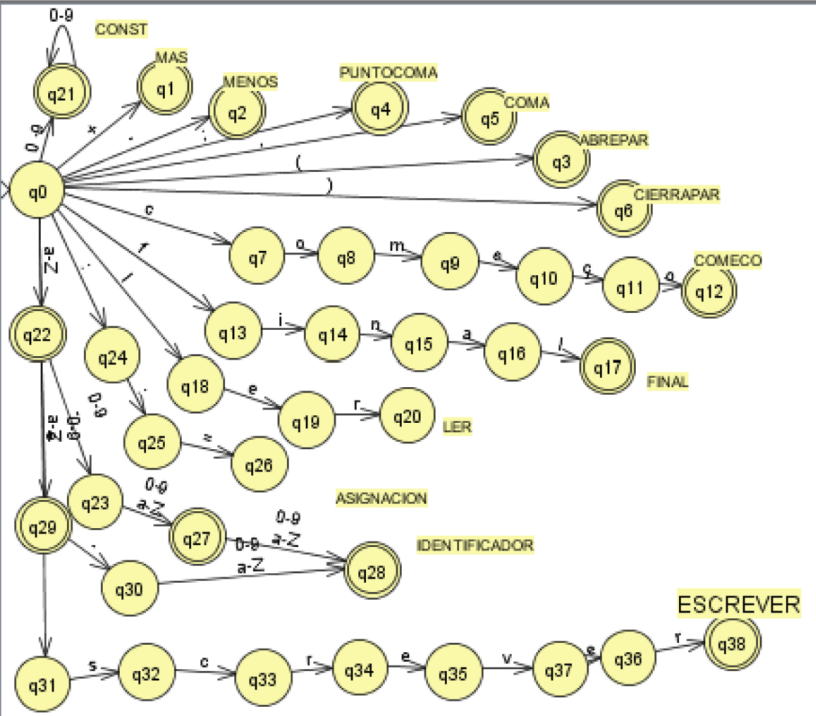

## Tabla de Transiciones

## Actividad de la cadena de estudio sobre el autómata

1. Estado=q0
2. Entrada=c
3. Estado=q7
4. Entrada=o
5. Estado=q8
6. Entrada=m
7. Estado=q9
8. Entrada=e
9. Estado=q10
10. Entrada=ç
11. Estado=q11
12. Entrada=o
13. Estado=q12
14. Token=COMEÇO
15. Lexema=começo
16. ...

## Implementación Scanner

In [96]:
%%file bra.py
import ply.lex as lex

reserved = {
   'começo' : 'COMECO',
   'final' : 'FINAL',
   'ler' : 'LER',
   'escrever' : 'ESCREVER'
}

# definir tokens
tokens  = ['MAS', 'MENOS', 'PUNTOCOMA', 'COMA', 'ABREPAR', 'CIERRAPAR', 'ASIGNACION', 'ID', 'CONST'] + list(reserved.values())

# definir patrones
t_MAS        = r'\+'
t_MENOS      = r'-'
t_PUNTOCOMA  = r'\;'
t_COMA       = r'\,'
t_ABREPAR    = r'\('
t_CIERRAPAR  = r'\)'
t_ASIGNACION = r'::='

def t_ID(t):
    r'[A-Za-z][A-Za-z0-9_ç]*'
    # Si coincide con palabra reservada, cambia tipo
    t.type = reserved.get(t.value, 'ID')
    return t

def t_CONST(t):
    r'[0-9]+'
    try:
        t.value = int(t.value)
    except ValueError:
        print("Integer value too large %d", t.value)
        t.value = 0
    return t

t_ignore = " \t"

def t_newline(t):
    r'\n+'
    t.lexer.lineno += t.value.count("\n")
    
def t_error(t):
    print("Illegal character '%s'" % t.value[0])
    t.lexer.skip(1)

# construir scanner
lexer = lex.lex()
lexer.input('começo A ::= 1; final')
while 1:
    tok = lexer.token()
    if not tok: break
    print(tok)

Overwriting bra.py


In [97]:
!python bra.py

LexToken(COMECO,'começo',1,0)
LexToken(ID,'A',1,7)
LexToken(ASIGNACION,'::=',1,9)
LexToken(CONST,1,1,13)
LexToken(PUNTOCOMA,';',1,14)
LexToken(FINAL,'final',1,16)


## GIC

```
<programa>        -> começo <listaSentencias> final
<listaSentencias> -> <sentencia> | <sentencia> <listaSentencias>
<sentencia>       -> <id> ::= <exp>; | ler(<listaID>); | escrever(<listaExp>);
<listaID>         -> <id> | <id> , <listaID>
<listaExp>        -> <exp> | <exp> , <listaExp>
<exp>             -> <primaria> | <primaria> <opeAditivo> <exp>
<primaria>        -> <id> | <cte> | (<exp>)  
```

```
P  -> começo LS final
LS -> S | S LS
S  -> ID ::= E; | ler(LI); | escrever(LE);
LI -> ID | ID , LI
LE -> E | E , LE
E  -> O | O OP E
O  -> ID | K | (E)  
```

## Derivación de la cadena de estudio

```
P => começo LS final 
  => começo S final
  => começo ID ::= E; final
  => começo ID ::= O; final
  => começo ID ::= K; final
```

```
       P
     / | \
começo LS final
       |
       S
    / / \ \
   ID ::= E ;
          |
          O
          |
          K
```

## ASDB: parser + parsing cadena de estudio

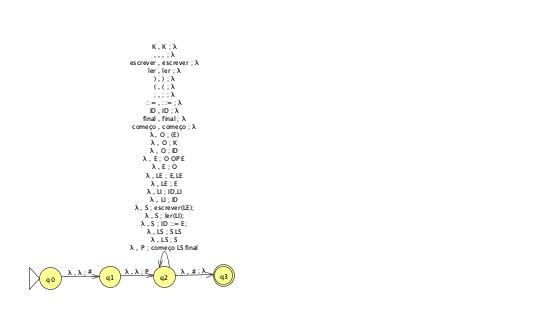

| Pila             | Entrada                | Transición                       |
| --               | --                     | --                               |
| λ                | começo ID ::= K; final | δ(q0,λ,λ) = (q1,#)               |
| #                | começo ID ::= K; final | δ(q1,λ,λ) = (q2,P)               |
| #P               | começo ID ::= K; final | δ(q2,λ,P) = (q2,começo LS final) |
| #final LS começo | começo ID ::= K; final | δ(q2,começo,começo) = (q2,λ)     |
| #final LS        | ID ::= K; final        | δ(q2,λ,LS) = (q2,S)              |
| #final S         | ID ::= K; final        | δ(q2,λ,S) = (q2,ID ::= E;)       |
| #final ;E ::= ID | ID ::= K; final        | δ(q2,ID,ID) = (q2,λ)             |
| #final ;E ::=    | ::= K; final           | δ(q2,::=,::=) = (q2,λ)           |
| #final ;E        | K; final               | δ(q2,λ,E) = (q2,O)               |
| #final ;O        | K; final               | δ(q2,λ,O) = (q2,K)               |
| #final ;K        | K; final               | δ(q2,K,K) = (q2,λ)               |
| #final ;         | ; final                | δ(q2,;,;) = (q2,λ)               |
| #final           | final                  | δ(q2,final,final) = (q2,λ)       |
| #                | λ                      | δ(q2,λ,#) = (q3,λ)               |
| λ                | λ                      | accept                           |

## ASAB: parser + parsing cadena de estudio

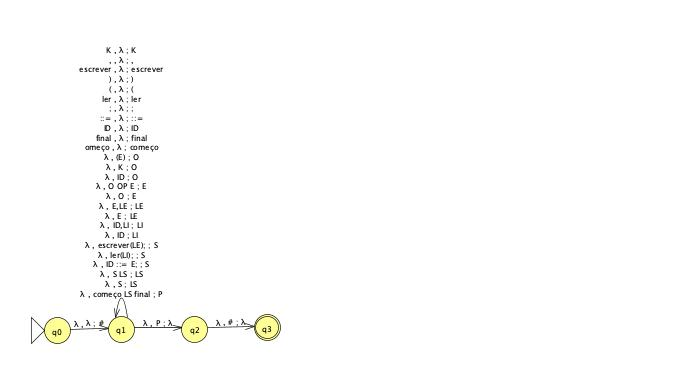

| Pila             | Entrada                | Transición                       |
| --               | --                     | --                               |
| λ                | começo ID ::= K; final | δ(q0,λ,λ) = (q1,#)               |
| #                | começo ID ::= K; final | δ(q1,começo,λ) = (q1,começo)     |
| #começo          | ID ::= K; final        | δ(q1,ID,λ) = (q1,ID)             |
| #começo ID       | ::= K; final           | δ(q1,::=,λ) = (q1,::=)           |
| #começo ID ::=   | K; final               | δ(q1,K,λ) = (q1,K)               |
| #começo ID ::= K | ; final                | δ(q1,λ,K) = (q1,O)               |
| #começo ID ::= O | ; final                | δ(q1,λ,O) = (q1,E)               |
| #começo ID ::= E | ; final                | δ(q1,;,λ) = (q1,;)               |
| #começo ID ::= E;| final                  | δ(q1,λ,ID ::= E;) = (q1,S)       |
| #começo S        | final                  | δ(q1,final,λ) = (q1,final)       |
| #começo S final  | λ                      | δ(q1,λ,começoSfinal) = (q1,P)    |
| #P               | λ                      | δ(q1,λ,P) = (q2,λ)               |
| #                | λ                      | δ(q2,λ,#) = (q3,λ)               |
| λ                | λ                      | accept                           |

## Diagrama de sintaxis

```
<programa> -> começo <listaSentencias> final

---->[<programa>]---->(começo)---->[<listaSentencias>]----(final)---->

...
```

## Implementación Parser

In [ ]:
%%file bra_parser.py
import ply.yacc as yacc

def p_programa(t):
    'programa : COMECO  lista_sentencias FINAL' 

def p_lista_sentencias(t):
    '''lista_sentencias : sentencia lista_sentencias
                        | sentencia'''

def p_sentencia(t):
    '''sentencia : id ::= exp;
                 | ler(lista_ID);
                 | escrever(lista_Exp);'''


def p_lista_id(t):
    '''lista_ID : id 
                | id , lista_ID'''


<listaExp>        -> <exp> | <exp> , <listaExp>
<exp>             -> <primaria> | <primaria> <opeAditivo> <exp>
<primaria>        -> <id> | <cte> | (<exp>)  
    
def p_error(t):
    print("Error sintáctico en '%s'" % t.value)

parser = yacc.yacc()
parser.parse('CSNNSOOONF')